Using device: cuda
Model parameters: 39,736,512
Starting training...
Epoch 1, Batch 0, Loss: 15368.4473
Epoch 1, Batch 100, Loss: 1760.3002
Epoch 1, Batch 200, Loss: 1587.5994
Epoch 1, Batch 300, Loss: 1500.4272
Epoch 1, Batch 400, Loss: 1477.7830
Epoch 1/50
  Train Loss: 1849.9264
  Val Loss: 1454.0446
  LR: 0.001000
Epoch 2, Batch 0, Loss: 1439.6130
Epoch 2, Batch 100, Loss: 1435.0642
Epoch 2, Batch 200, Loss: 1427.9951
Epoch 2, Batch 300, Loss: 1400.1217
Epoch 2, Batch 400, Loss: 1389.9875
Epoch 2/50
  Train Loss: 1420.1068
  Val Loss: 1393.0190
  LR: 0.001000
Epoch 3, Batch 0, Loss: 1397.8406
Epoch 3, Batch 100, Loss: 1381.4976
Epoch 3, Batch 200, Loss: 1372.0978
Epoch 3, Batch 300, Loss: 1372.0060
Epoch 3, Batch 400, Loss: 1371.0820
Epoch 3/50
  Train Loss: 1379.3278
  Val Loss: 1364.7113
  LR: 0.001000
Epoch 4, Batch 0, Loss: 1361.5710
Epoch 4, Batch 100, Loss: 1365.7966
Epoch 4, Batch 200, Loss: 1353.2747
Epoch 4, Batch 300, Loss: 1351.0144
Epoch 4, Batch 400, Loss: 1347.8959
Ep

/tmp/ipykernel_7390/1385818159.py:394: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


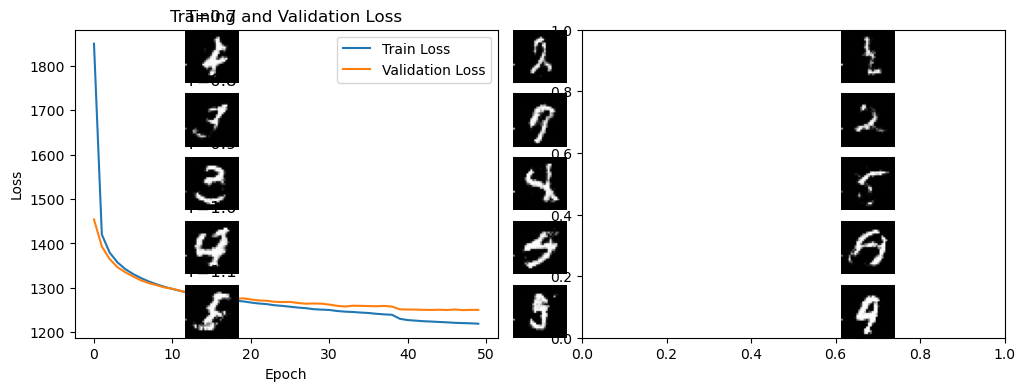

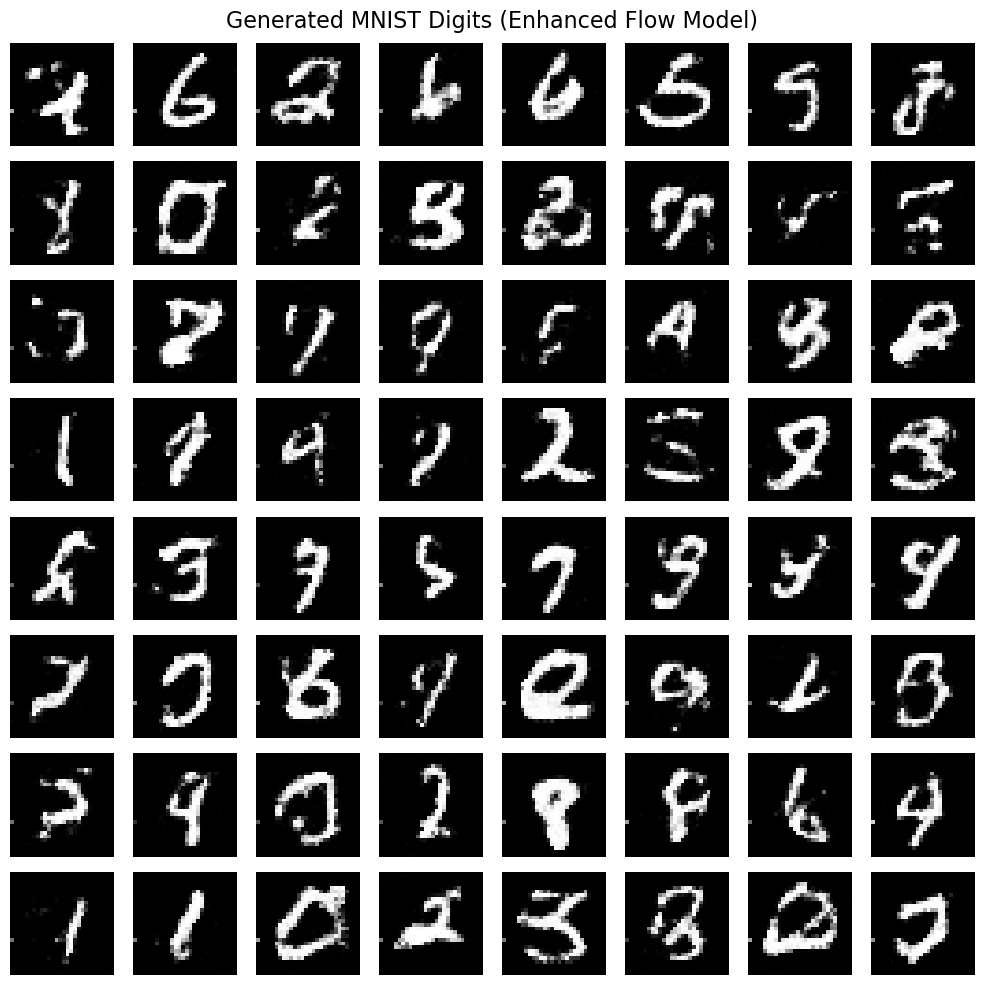

Final validation loss: 1249.7928
Training completed!


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
import math

# Initialize enhanced model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}") 

# ---- 1. Enhanced Data Preparation ----
def uniform_dequantize(x):
    """Add uniform noise for dequantization"""
    u = torch.rand_like(x)
    x_deq = (x * 255.0 + u) / 256.0
    return x_deq

def logit_transform(x, alpha=1e-6):
    """Logit transformation to map [0,1] to (-inf, inf)"""
    # Add small noise to avoid 0 and 1
    x = alpha + (1 - 2*alpha) * x
    return torch.log(x / (1 - x))

def inverse_logit_transform(z, alpha=1e-6):
    """Inverse logit transformation"""
    x = torch.sigmoid(z)
    # Remove the alpha padding
    x = (x - alpha) / (1 - 2*alpha)
    return torch.clamp(x, 0, 1)

# Enhanced preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(uniform_dequantize),
    transforms.Lambda(lambda x: logit_transform(x))
])

# Create train/validation split
full_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)

# ---- 2. Enhanced Coupling Layer with Better Networks ----
class MaskedLinear(nn.Module):
    """Linear layer with masking for autoregressive flows"""
    def __init__(self, in_features, out_features, mask):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.register_buffer('mask', mask)
    
    def forward(self, x):
        return F.linear(x, self.linear.weight * self.mask, self.linear.bias)

class EnhancedAffineCoupling(nn.Module):
    def __init__(self, dim, hidden_dim, mask_type='checkerboard'):
        super().__init__()
        self.dim = dim
        self.mask_type = mask_type
        
        # Create mask for coupling (start on CPU, will be moved to device later)
        if mask_type == 'checkerboard':
            # For 2D data like images, checkerboard pattern works better
            h, w = int(np.sqrt(dim)), int(np.sqrt(dim))
            mask = torch.zeros(h, w)
            mask[::2, ::2] = 1
            mask[1::2, 1::2] = 1
            self.register_buffer('mask', mask.flatten()[:dim])
        else:
            # Simple split
            mask = torch.zeros(dim)
            mask[:dim//2] = 1
            self.register_buffer('mask', mask)
        
        masked_size = int(self.mask.sum().item())
        
        # More sophisticated network with residual connections
        self.net = nn.Sequential(
            nn.Linear(masked_size, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, (dim - masked_size) * 2)  # scale and translation
        )
        
        # Initialize last layer to near zero for stable training
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        # Apply mask to get conditional and transformation parts
        x_masked = x * self.mask
        x_unchanged = x * (1 - self.mask)
        
        # Get input for the transformation network (only masked part)
        # Extract features where mask == 1 for each sample in the batch
        net_input = x_masked[:, self.mask.bool()]
        
        st = self.net(net_input)
        unmasked_size = int((1 - self.mask).sum().item())
        s, t = st.chunk(2, dim=1)
        
        # Apply scaling with better stability
        s = torch.tanh(s) * 2  # Scale factor in [-2, 2]
        
        # Apply transformation only to unmasked part
        # Broadcast s and t to match the shape of the unmasked part
        s_full = torch.zeros_like(x)
        t_full = torch.zeros_like(x)
        
        # Fill in the transformation parameters for unmasked positions
        s_full[:, (1 - self.mask).bool()] = s
        t_full[:, (1 - self.mask).bool()] = t
        
        # Apply transformation
        y = x_masked + x_unchanged * torch.exp(s_full) + t_full
        log_det = s.sum(dim=1)  # Only sum over transformed dimensions
        
        return y, log_det

    def inverse(self, y):
        y_masked = y * self.mask
        y_unchanged = y * (1 - self.mask)
        
        # Get transformation parameters from masked part
        net_input = y_masked[:, self.mask.bool()]
        st = self.net(net_input)
        s, t = st.chunk(2, dim=1)
        s = torch.tanh(s) * 2
        
        # Broadcast s and t to match full shape
        s_full = torch.zeros_like(y)
        t_full = torch.zeros_like(y)
        s_full[:, (1 - self.mask).bool()] = s
        t_full[:, (1 - self.mask).bool()] = t
        
        # Apply inverse transformation
        x = y_masked + (y_unchanged - t_full) * torch.exp(-s_full)
        
        return x

# ---- 3. Better Permutation Layers ----
class RandomPermutation(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # Fixed random permutation
        perm = torch.randperm(dim)
        inv_perm = torch.empty_like(perm)
        inv_perm[perm] = torch.arange(dim)
        
        self.register_buffer('perm', perm)
        self.register_buffer('inv_perm', inv_perm)

    def forward(self, x):
        return x[:, self.perm], 0

    def inverse(self, y):
        return y[:, self.inv_perm]

class Squeeze(nn.Module):
    """Squeeze operation for multi-scale flows"""
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        # Reshape from (B, H*W) to (B, 4, H/2*W/2) for 2x2 squeeze
        B, HW = x.shape
        H = W = int(np.sqrt(HW))
        
        # Only apply if dimensions are even
        if H % 2 == 0 and W % 2 == 0:
            x_reshaped = x.view(B, H, W)
            x_squeezed = x_reshaped.view(B, H//2, 2, W//2, 2)
            x_squeezed = x_squeezed.permute(0, 2, 4, 1, 3).contiguous()
            x_squeezed = x_squeezed.view(B, 4 * (H//2) * (W//2))
            return x_squeezed, 0
        return x, 0
    
    def inverse(self, y):
        B, channels_HW = y.shape
        if channels_HW % 4 == 0:
            HW = channels_HW // 4
            H = W = int(np.sqrt(HW))
            
            y_reshaped = y.view(B, 2, 2, H, W)
            y_unsqueezed = y_reshaped.permute(0, 3, 1, 4, 2).contiguous()
            y_unsqueezed = y_unsqueezed.view(B, H*2*W*2)
            return y_unsqueezed
        return y

# ---- 4. Enhanced Flow Model ----
class EnhancedFlow(nn.Module):
    def __init__(self, n_blocks, dim, hidden_dim, use_squeeze=True):
        super().__init__()
        self.dim = dim
        self.use_squeeze = use_squeeze
        
        layers = []
        current_dim = dim
        
        # Add initial squeeze if using multi-scale
        if use_squeeze and int(np.sqrt(dim)) % 2 == 0:
            layers.append(Squeeze())
            current_dim = dim  # Squeeze doesn't change total dimension
        
        # Alternate between different mask types for better mixing
        for i in range(n_blocks):
            mask_type = 'checkerboard' if i % 2 == 0 else 'split'
            layers.append(EnhancedAffineCoupling(current_dim, hidden_dim, mask_type))
            
            # Add permutation every few layers
            if (i + 1) % 2 == 0:
                layers.append(RandomPermutation(current_dim))
        
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        log_det_sum = 0
        for layer in self.layers:
            if hasattr(layer, 'forward'):
                if isinstance(layer, EnhancedAffineCoupling):
                    x, log_det = layer(x)
                    log_det_sum += log_det
                else:
                    x, log_det = layer(x)
                    log_det_sum += log_det
        return x, log_det_sum

    def inverse(self, z):
        for layer in reversed(self.layers):
            z = layer.inverse(z)
        return z

# ---- 5. Enhanced Training with Validation ----
def validate_model(model, val_loader, device):
    model.eval()
    total_val_loss = 0
    total_samples = 0
    
    with torch.no_grad():
        for x, _ in val_loader:
            x = x.view(-1, model.dim).to(device)
            z, log_det = model(x)
            
            # Log-probability under standard normal
            log_prob = -0.5 * (z ** 2).sum(dim=1) - 0.5 * model.dim * np.log(2 * np.pi)
            loss = -(log_prob + log_det).mean()
            
            total_val_loss += loss.item() * x.size(0)
            total_samples += x.size(0)
    
    return total_val_loss / total_samples


dim = 28*28
hidden_dim = 1024  # Increased capacity
n_blocks = 12      # More blocks for better expressivity
flow = EnhancedFlow(n_blocks, dim, hidden_dim).to(device)

# Better optimizer settings
optimizer = optim.AdamW(flow.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

epochs = 50
best_val_loss = float('inf')
patience_counter = 0
patience = 10

print(f"Model parameters: {sum(p.numel() for p in flow.parameters()):,}")
print("Starting training...")

train_losses = []
val_losses = []

for epoch in range(epochs):
    # Training
    flow.train()
    total_train_loss = 0
    total_train_samples = 0
    
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.view(-1, dim).to(device)
        
        # Forward pass
        z, log_det = flow(x)
        
        # Compute loss (negative log-likelihood)
        log_prob = -0.5 * (z ** 2).sum(dim=1) - 0.5 * dim * np.log(2 * np.pi)
        loss = -(log_prob + log_det).mean()
        
        # Add small regularization to prevent instability
        reg_loss = 1e-5 * sum(torch.norm(p) for p in flow.parameters())
        total_loss = loss + reg_loss
        
        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(flow.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_train_loss += loss.item() * x.size(0)
        total_train_samples += x.size(0)
        
        if batch_idx % 100 == 0:
            print(f'Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}')
    
    # Validation
    val_loss = validate_model(flow, val_loader, device)
    scheduler.step(val_loss)
    
    avg_train_loss = total_train_loss / total_train_samples
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(flow.state_dict(), 'best_flow_model.pth')
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print("Early stopping triggered")
        break

# Load best model
flow.load_state_dict(torch.load('best_flow_model.pth'))

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# ---- 6. Enhanced Sampling with Temperature Control ----
def sample_with_temperature(model, n_samples, temperature=1.0, device='cpu'):
    """Sample from the model with temperature control"""
    model.eval()
    with torch.no_grad():
        # Sample from scaled normal distribution
        z = torch.randn(n_samples, model.dim).to(device) * temperature
        samples = model.inverse(z)
        
        # Apply inverse logit transform to get back to [0,1]
        samples = inverse_logit_transform(samples)
        samples = torch.clamp(samples, 0, 1)
        
        return samples.view(-1, 1, 28, 28)

# Generate samples with different temperatures
plt.subplot(1, 2, 2)
temperatures = [0.7, 0.8, 0.9, 1.0, 1.1]
for i, temp in enumerate(temperatures):
    samples = sample_with_temperature(flow, 64, temperature=temp, device=device)
    
    # Plot a few samples for each temperature
    for j in range(3):
        plt.subplot(len(temperatures), 3, i*3 + j + 1)
        plt.imshow(samples[j*8].squeeze().cpu(), cmap='gray')
        plt.axis('off')
        if j == 0:
            plt.title(f'T={temp}')

plt.tight_layout()
plt.show()

# Generate a grid of high-quality samples
flow.eval()
with torch.no_grad():
    samples = sample_with_temperature(flow, 64, temperature=0.8, device=device)

# Plot final sample grid
fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i in range(8):
    for j in range(8):
        axes[i, j].imshow(samples[i*8 + j].squeeze().cpu(), cmap='gray')
        axes[i, j].axis('off')
plt.suptitle('Generated MNIST Digits (Enhanced Flow Model)', fontsize=16)
plt.tight_layout()
plt.show()

print(f"Final validation loss: {best_val_loss:.4f}")
print("Training completed!")
